<center><p float="center">
  <img src="https://upload.wikimedia.org/wikipedia/commons/e/e9/4_RGB_McCombs_School_Brand_Branded.png" width="300" height="100"/>
  <img src="https://mma.prnewswire.com/media/1458111/Great_Learning_Logo.jpg?p=facebook" width="200" height="100"/>
</p></center>

<center><font size=10>Artificial Intelligence and Machine Learning</font></center>
<center><font size=6>Advanced Machine Learning - Project Debrief</font></center>

<center><img src="https://images.pexels.com/photos/7235894/pexels-photo-7235894.jpeg?auto=compress&cs=tinysrgb&w=1260&h=750&dpr=2" width="800" height="500"></center>

<center><font size=6>Visa Approval Facilitation</font></center>

## Problem Statement

### Context:

Business communities in the United States are facing high demand for human resources, but one of the constant challenges is identifying and attracting the right talent, which is perhaps the most important element in remaining competitive. Companies in the United States look for hard-working, talented, and qualified individuals both locally as well as abroad.

The Immigration and Nationality Act (INA) of the US permits foreign workers to come to the United States to work on either a temporary or permanent basis. The act also protects US workers against adverse impacts on their wages or working conditions by ensuring US employers' compliance with statutory requirements when they hire foreign workers to fill workforce shortages. The immigration programs are administered by the Office of Foreign Labor Certification (OFLC).

OFLC processes job certification applications for employers seeking to bring foreign workers into the United States and grants certifications in those cases where employers can demonstrate that there are not sufficient US workers available to perform the work at wages that meet or exceed the wage paid for the occupation in the area of intended employment.

### Objective:

In FY 2016, the OFLC processed 775,979 employer applications for 1,699,957 positions for temporary and permanent labor certifications. This was a nine percent increase in the overall number of processed applications from the previous year. The process of reviewing every case is becoming a tedious task as the number of applicants is increasing every year.

The increasing number of applicants every year calls for a Machine Learning based solution that can help in shortlisting the candidates having higher chances of VISA approval. OFLC has hired the firm EasyVisa for data-driven solutions. You as a data  scientist at EasyVisa have to analyze the data provided and, with the help of a classification model:

* Facilitate the process of visa approvals.
* Recommend a suitable profile for the applicants for whom the visa should be certified or denied based on the drivers that significantly influence the case status.

### Data Description

The data contains the different attributes of employee and the employer. The detailed data dictionary is given below.

* case_id: ID of each visa application
* continent: Information of continent the employee
* education_of_employee: Information of education of the employee
* has_job_experience: Does the employee has any job experience? Y= Yes; N = No
* requires_job_training: Does the employee require any job training? Y = Yes; N = No
* no_of_employees: Number of employees in the employer's company
* yr_of_estab: Year in which the employer's company was established
* region_of_employment: Information of foreign worker's intended region of employment in the US.
* prevailing_wage:  Average wage paid to similarly employed workers in a specific occupation in the area of intended employment. The purpose of the prevailing wage is to ensure that the foreign worker is not underpaid compared to other workers offering the same or similar service in the same area of employment.
* unit_of_wage: Unit of prevailing wage. Values include Hourly, Weekly, Monthly, and Yearly.
* full_time_position: Is the position of work full-time? Y = Full Time Position; N = Part Time Position
* case_status:  Flag indicating if the Visa was certified or denied

## Importing necessary libraries

In [114]:
import warnings
warnings.filterwarnings('ignore')

In [115]:
# Installing the libraries with the specified version.
!pip install numpy==1.26 pandas==2.2.2 scikit-learn==1.5.2 matplotlib==3.8.0 seaborn==0.13.1 xgboost==2.0.3 -q --user

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.5/58.5 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 77.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.3/13.3 MB 91.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 69.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.8/294.8 kB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 297.1/297.1 MB 2.0 MB/s eta 0:00:00
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


**Note**: *After running the above cell, kindly restart the notebook kernel and run all cells sequentially from the below.*

In [2]:
#libraries to read and manipulate data
import numpy as np
import pandas as pd

#libraries to visualize data
import matplotlib.pyplot as plt
import seaborn as sns

#libraries for model building and tuning
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (BaggingClassifier,RandomForestClassifier,
                              GradientBoostingClassifier, AdaBoostClassifier, StackingClassifier)
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

#libraries for metrics and statistics
from sklearn import metrics
import scipy.stats as stats
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score, roc_auc_score

import warnings
warnings.filterwarnings('ignore')

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
#pointing to path where project notebook is present
%cd '/content/drive/MyDrive/PGP ML/Project_3ML_EasyVisa_Project'

/content/drive/MyDrive/PGP ML/Project_3ML_EasyVisa_Project


## Import Dataset

In [5]:
#Reading csv file from above path into a Pandas Dataframe
visa = pd.read_csv('EasyVisa.csv')
# Preserve original data
df_original = visa.copy()
#Working copy
df = visa.copy()

## Overview of the Dataset

In [6]:
# print first five rows
df.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


#### View the first and last 5 rows of the dataset

In [7]:
# print last five rows
df.tail()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.57,Year,Y,Certified
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.79,Year,Y,Certified
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.85,Year,N,Certified
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.77,Year,Y,Certified
25479,EZYV25480,Asia,Bachelor's,Y,N,3195,1960,Midwest,70876.91,Year,Y,Certified


#### Understand the shape of the dataset

In [8]:
#shape
df.shape

(25480, 12)

#### Observations
#### Dataset has 25,480 rows and 12 columns

#### Check the data types of the columns for the dataset

In [9]:
#Data types of the columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  object 
 1   continent              25480 non-null  object 
 2   education_of_employee  25480 non-null  object 
 3   has_job_experience     25480 non-null  object 
 4   requires_job_training  25480 non-null  object 
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  object 
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  object 
 10  full_time_position     25480 non-null  object 
 11  case_status            25480 non-null  object 
dtypes: float64(1), int64(2), object(9)
memory usage: 2.3+ MB


#### check for dups

In [10]:
#Duplicate value exists in columns:
df.duplicated().sum()

np.int64(0)

In [11]:
df[df.duplicated()]

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status


##### Since the result of the dupliate function returned a 64-bit integer from NumPy, that indicate that the count of duplicate rows is 0. That means there are no duplicates.

#### Observations:
#### There are no duplicate rows/values in the df_original dataset.
#### It is recommended to convert object ype columns into categories so that overall memory requirement to store the data frame will come down.

#### There are 9 columns of type Object, 1 columns of type "float64", and 2 columns of the "int64".

#### The target variable for the model is case_status.

#### case_id is a randomly assigned by INA for each case, which should not provide any material information for model building.

In [12]:
## Convert all columns with dtype object into category
for col in df.columns[df.dtypes == 'object']:
    df[col] = df[col].astype('category')

In [13]:
# drop the column *case_id* from the dataframe: df: working copy
df.drop(labels='case_id', axis=1, inplace=True)

In [14]:
#check if case_id is dropped from data frame df
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   continent              25480 non-null  category
 1   education_of_employee  25480 non-null  category
 2   has_job_experience     25480 non-null  category
 3   requires_job_training  25480 non-null  category
 4   no_of_employees        25480 non-null  int64   
 5   yr_of_estab            25480 non-null  int64   
 6   region_of_employment   25480 non-null  category
 7   prevailing_wage        25480 non-null  float64 
 8   unit_of_wage           25480 non-null  category
 9   full_time_position     25480 non-null  category
 10  case_status            25480 non-null  category
dtypes: category(8), float64(1), int64(2)
memory usage: 797.7 KB


#### Compared to the data frame before dropping case_id, the size is reduced by 1/3rd of original size

## Exploratory Data Analysis (EDA)

#### Let's check the statistical summary of the data

In [15]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
continent,25480,6,Asia,16861,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education_of_employee,25480,4,Bachelor's,10234,NaN,NaN,NaN,NaN,NaN,NaN,NaN
has_job_experience,25480,2,Y,14802,NaN,NaN,NaN,NaN,NaN,NaN,NaN
requires_job_training,25480,2,N,22525,NaN,NaN,NaN,NaN,NaN,NaN,NaN
no_of_employees,25480.0,NaN,NaN,NaN,5667.04321,22877.928848,-26.0,1022.0,2109.0,3504.0,602069.0
yr_of_estab,25480.0,NaN,NaN,NaN,1979.409929,42.366929,1800.0,1976.0,1997.0,2005.0,2016.0
region_of_employment,25480,5,Northeast,7195,NaN,NaN,NaN,NaN,NaN,NaN,NaN
prevailing_wage,25480.0,NaN,NaN,NaN,74455.814592,52815.942327,2.1367,34015.48,70308.21,107735.5125,319210.27
unit_of_wage,25480,4,Year,22962,NaN,NaN,NaN,NaN,NaN,NaN,NaN
full_time_position,25480,2,Y,22773,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### Observations from Summary Data
#### 1. The dataset contains 25,480 records. The dataset consists of both numerical and categorical variables.

#### 2. The dataset shows a clear dominance of certain categories (e.g., Asia for continent, Bachelor’s for education, and Certified for case_status). This suggests that data might be heavily weighted toward a specific group of applicants.

#### 3. Data Quality issues: Number of employees needs to be corrected before proceeding further

#### Fixing the negative values in number of employees columns

In [16]:
# Count negative values for awareness
negative_count = (df['no_of_employees'] < 0).sum()
print(f"Number of negative values: {negative_count}")


Number of negative values: 33


##### **Given that only 33 out of 25,480 records (roughly 0.13%) have negative values for the number of employees—a figure that is nearly negligible, I am dropping these 33 records.**

In [17]:
# Drop records with negative no_of_employees
df_cleaned = df[df['no_of_employees'] >= 0].copy()

# Check the new dataset size
print(f"New dataset size: {df_cleaned.shape[0]}")

New dataset size: 25447


In [18]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 25447 entries, 0 to 25479
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   continent              25447 non-null  category
 1   education_of_employee  25447 non-null  category
 2   has_job_experience     25447 non-null  category
 3   requires_job_training  25447 non-null  category
 4   no_of_employees        25447 non-null  int64   
 5   yr_of_estab            25447 non-null  int64   
 6   region_of_employment   25447 non-null  category
 7   prevailing_wage        25447 non-null  float64 
 8   unit_of_wage           25447 non-null  category
 9   full_time_position     25447 non-null  category
 10  case_status            25447 non-null  category
dtypes: category(8), float64(1), int64(2)
memory usage: 995.3 KB


In [19]:
#check top 5 records
df_cleaned.head()

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


#### I am going to use **df_cleaned** as the go forward data frame for the model design

#### Let's check the count of each unique category in each of the categorical variables

In [20]:
# Select categorical columns (if some categorical variables are of object type, include that as well)
categorical_columns = df_cleaned.select_dtypes(include=['category', 'object']).columns

# Iterate through each categorical column and print the counts of unique values
for col in categorical_columns:
    print(f"Counts for column '{col}':")
    print(df_cleaned[col].value_counts())
    print("\n")

Counts for column 'continent':
continent
Asia             16840
Europe            3727
North America     3287
South America      851
Africa             550
Oceania            192
Name: count, dtype: int64


Counts for column 'education_of_employee':
education_of_employee
Bachelor's     10220
Master's        9622
High School     3416
Doctorate       2189
Name: count, dtype: int64


Counts for column 'has_job_experience':
has_job_experience
Y    14786
N    10661
Name: count, dtype: int64


Counts for column 'requires_job_training':
requires_job_training
N    22498
Y     2949
Name: count, dtype: int64


Counts for column 'region_of_employment':
region_of_employment
Northeast    7189
South        7006
West         6578
Midwest      4299
Island        375
Name: count, dtype: int64


Counts for column 'unit_of_wage':
unit_of_wage
Year     22933
Hour      2153
Week       272
Month       89
Name: count, dtype: int64


Counts for column 'full_time_position':
full_time_position
Y    22741
N     

### Univariate Analysis

In [21]:
def histogram_boxplot(data, feature, figsize=(15, 10), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (15,10))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a triangle will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

In [22]:
# function to create labeled barplots


def labeled_barplot(data, feature, feature_2, order, perc=False, n=None):
    """
    Creates a bar plot for a categorical variable with labels showing either counts or percentages.

    Parameters:
      data       : pandas.DataFrame
                   The input DataFrame containing data.
      feature    : str
                   The name of the column to plot on the x-axis (primary category).
      feature_2  : str
                   The name of the column used to color (hue) the bars (secondary category).
      order      : list
                   The ordered list of categories for the x-axis.
      perc       : bool, default False
                   If True, displays percentage values on top of each bar instead of raw counts.
      n          : int or None, default None
                   If n, limits the plot to the top n categories. If None, all categories are shown.
    """

    # Calculate the total number of observations for the given feature.
    total = len(data[feature])

    # Count the number of unique categories in the feature.
    unique_categories = data[feature].nunique()

    # Determine the figure size:
    # - If n is not provided, use the number of unique categories plus some extra space.
    # - If n is provided, use n to determine the x dimension.
    if n is None:
        plt.figure(figsize=(unique_categories + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    # Create a count plot with seaborn.
    # - 'x=feature' sets the x-axis as the provided feature.
    # - 'hue=feature_2' splits the bars by a second feature, showing different colors.
    # - 'order=order' forces the bars to be in the specified order.
    ax = sns.countplot(
        data=data,
        x=feature,
        hue=feature_2,
        palette='viridis',
        order=order,
    )

    # Iterate over each rectangle (bar) in the plot.
    for p in ax.patches:
        # Determine the label:
        # If perc=True, calculate the percentage for this bar.
        # Otherwise, choose the raw count (height of the bar).
        if perc:
            # p.get_height() gives the count for this bar.
            # Multiply by 100/total to get the percentage and format it to one decimal place.
            label = "{:.1f}%".format(100 * p.get_height() / total)
        else:
            label = str(int(p.get_height()))

        # Calculate the horizontal center of the bar.
        # p.get_x() is the x coordinate of the bar,
        # p.get_width() is the width of the bar.
        x_position = p.get_x() + p.get_width() / 2

        # The y position is just the top of the bar.
        y_position = p.get_height()


        ax.annotate(
            label,                          # The label text.
            (x_position, y_position),       # Position (x,y) on the plot.
            ha="center",                    # Horizontal alignment.
            va="center",                    # Vertical alignment.
            size=9,                         # Font size.
            xytext=(0, 5),                  # Offset the text 5 points above the bar.
            textcoords="offset points"      # Specify that the offset is in points.
        )

    # Display the plot.
    plt.show()

#### **Creating bins (range) to categorize companies:**

1. By the size of their overall workforce and
2. By number of years since the company was founded



In [23]:
#create bins to categorize companies by the size of their overall workforce
bins = [0,1000,2000,3000,4000,np.inf]
names = ['0-1000','1000-2000','2000-3000','3000-4000','4000+']
#assign each applicant to a category which indicates the size of the company he or she is applying to
df_cleaned['company_size'] = pd.cut(df_cleaned['no_of_employees'], bins, labels=names)
df_cleaned.company_size.value_counts()

,count
company_size,
0-1000,6208
1000-2000,5915
2000-3000,4978
4000+,4798
3000-4000,3548


In [24]:
#create bins to categorize companies by the number of years since the company was founded
bins = [0,1966,1986,1996,2006,np.inf]
names = ['50+','30-50','20-30','10-20','0-10']
#assign each applicant to a category which indicates how long the company has been in business (i.e., a proxy for how well-established the company is)
df_cleaned['company_age'] = pd.cut(df_cleaned['yr_of_estab'], bins, labels=names)
df_cleaned.company_age.value_counts()

,count
company_age,
10-20,8367
50+,5106
0-10,4849
30-50,3739
20-30,3386


#### Observations on education of employee

In [25]:
#Association of Education with Visa outcomes:
edu_status = pd.crosstab(df_cleaned['education_of_employee'], df['case_status'])
edu_status

case_status,Certified,Denied
education_of_employee,,
Bachelor's,6362,3858
Doctorate,1910,279
High School,1164,2252
Master's,7565,2057


#### **Observations**:

#### Applicants with High School as education qualification has higher deniel rate (66%) compared to any other education type.

#### Cases with Doctorate as education type has very less deniel rate compared to other education types

#### Observations on region of employment

In [26]:
#group data by continent and count the numbers of each case_status for each category
df_cleaned.groupby('continent')['case_status'].value_counts(normalize=True)

continent      case_status
Africa         Certified      0.720000
               Denied         0.280000
Asia           Certified      0.653266
               Denied         0.346734
Europe         Certified      0.792326
               Denied         0.207674
North America  Certified      0.619714
               Denied         0.380286
Oceania        Certified      0.635417
               Denied         0.364583
South America  Certified      0.578143
               Denied         0.421857
Name: proportion, dtype: float64

#### **Observations**:
#### Europe stands out with a very high approval rate.

#### South America has the lowest approval rate, with nearly 42% of applications denied.

#### Africa, Asia, Oceania, and North America fall in between, with varying balance between certification and denial.

#### Observations on job experience

In [27]:
#To compare the likelihood (or proportions) of certification between candidates with and without job experience, it’s beneficial to see the percentages rather than just raw counts.
df_cleaned.groupby('has_job_experience')['case_status'].value_counts(normalize=True)

has_job_experience  case_status
N                   Certified      0.561486
                    Denied         0.438514
Y                   Certified      0.744961
                    Denied         0.255039
Name: proportion, dtype: float64

#### **Observations**: Impact of Job Experience on Certification Rates

#### **Higher Success Rate for Experienced Applicants**:

#### Applicants with job experience have an 18 percentage point higher certification rate compared to those without job experience. This suggests that job experience is a significant factor in the certification decision.

#### **Lower Denial Rate for Experienced Applicants:**

#### The denial rate drops from approximately 43.87% for those without experience to about 25.52% for those with experience. This further reinforces the idea that job experience may be viewed as a key qualification for granting visa application.

#### Observations on case status

In [28]:
df_cleaned['case_status'].value_counts()

,count
case_status,
Certified,17001
Denied,8446


#### **Observations on class imbalance**

#### The distribution of 17,001 Certified versus 8,446 Denied cases (roughly a 2:1 ratio, or about 67% Certified and 33% Denied) indicates a form of class imbalance.

### Bivariate Analysis

**Creating functions that will help us with further analysis.**

In [29]:
### function to plot distributions wrt target


def distribution_plot_wrt_target(data, predictor, target):

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    target_uniq = data[target].unique()

    axs[0, 0].set_title("Distribution of target for target=" + str(target_uniq[0]))
    sns.histplot(
        data=data[data[target] == target_uniq[0]],
        x=predictor,
        kde=True,
        ax=axs[0, 0],
        color="teal",
        stat="density",
    )

    axs[0, 1].set_title("Distribution of target for target=" + str(target_uniq[1]))
    sns.histplot(
        data=data[data[target] == target_uniq[1]],
        x=predictor,
        kde=True,
        ax=axs[0, 1],
        color="orange",
        stat="density",
    )

    axs[1, 0].set_title("Boxplot w.r.t target")
    sns.boxplot(data=data, x=target, y=predictor, ax=axs[1, 0], palette="gist_rainbow")

    axs[1, 1].set_title("Boxplot (without outliers) w.r.t target")
    sns.boxplot(
        data=data,
        x=target,
        y=predictor,
        ax=axs[1, 1],
        showfliers=False,
        palette="gist_rainbow",
    )

    plt.tight_layout()
    plt.show()

In [30]:
def stacked_barplot(data, predictor, target):
    """
    Print the category counts and plot a stacked bar chart

    data: dataframe
    predictor: independent variable
    target: target variable
    """
    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )
    tab.plot(kind="bar", stacked=True, figsize=(count + 5, 5))
    plt.legend(
        loc="lower left", frameon=False,
    )
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

continent    Africa   Asia  Europe  North America  Oceania  South America  \
case_status                                                                 
All             550  16840    3727           3287      192            851   
Certified       396  11001    2953           2037      122            492   
Denied          154   5839     774           1250       70            359   

continent      All  
case_status         
All          25447  
Certified    17001  
Denied        8446  
------------------------------------------------------------------------------------------------------------------------


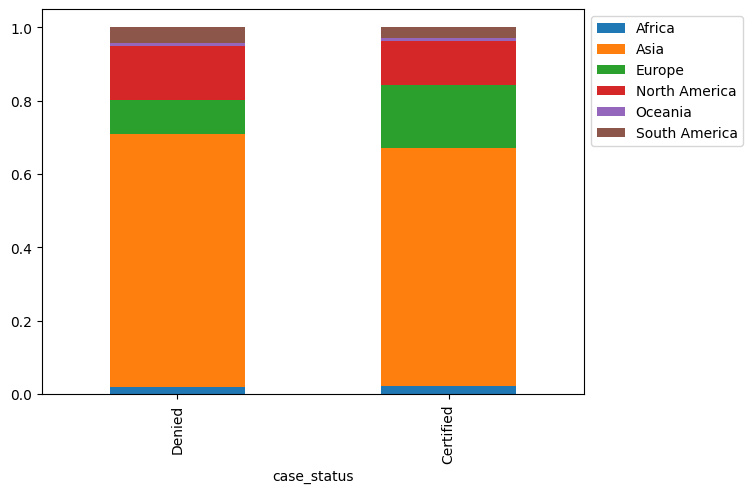

education_of_employee  Bachelor's  Doctorate  High School  Master's    All
case_status                                                               
All                         10220       2189         3416      9622  25447
Certified                    6362       1910         1164      7565  17001
Denied                       3858        279         2252      2057   8446
------------------------------------------------------------------------------------------------------------------------


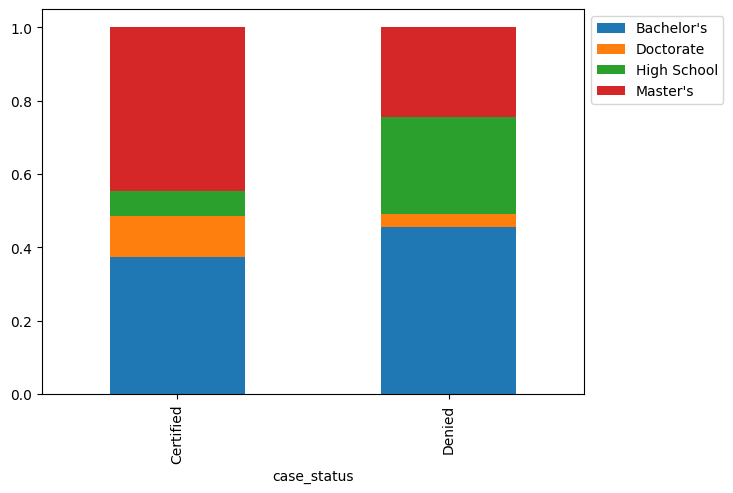

has_job_experience      N      Y    All
case_status                            
All                 10661  14786  25447
Certified            5986  11015  17001
Denied               4675   3771   8446
------------------------------------------------------------------------------------------------------------------------


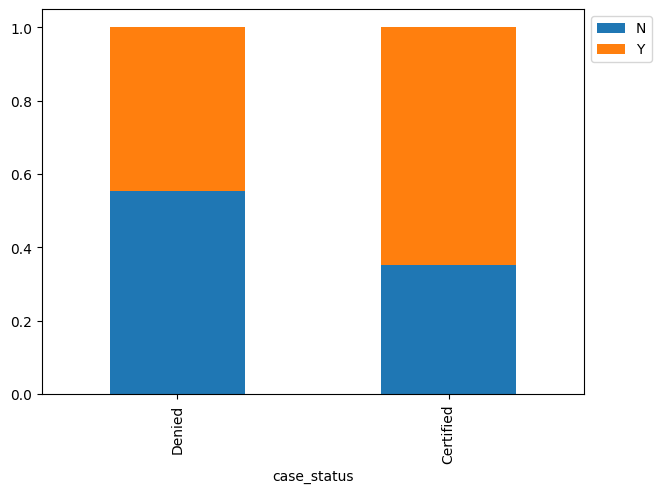

requires_job_training      N     Y    All
case_status                              
All                    22498  2949  25447
Certified              15000  2001  17001
Denied                  7498   948   8446
------------------------------------------------------------------------------------------------------------------------


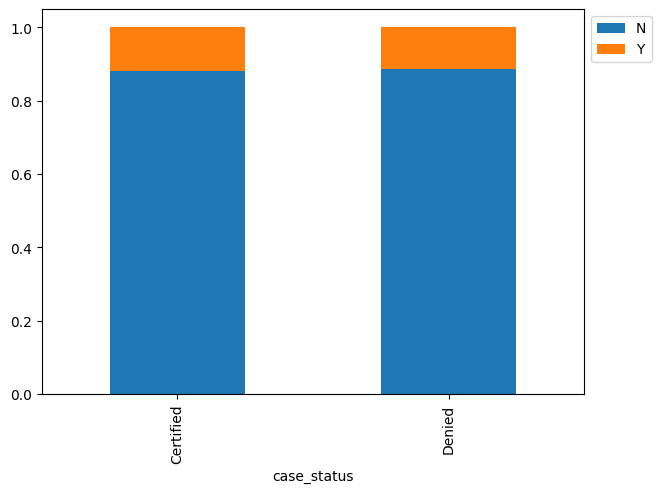

region_of_employment  Island  Midwest  Northeast  South  West    All
case_status                                                         
All                      375     4299       7189   7006  6578  25447
Certified                226     3246       4524   4908  4097  17001
Denied                   149     1053       2665   2098  2481   8446
------------------------------------------------------------------------------------------------------------------------


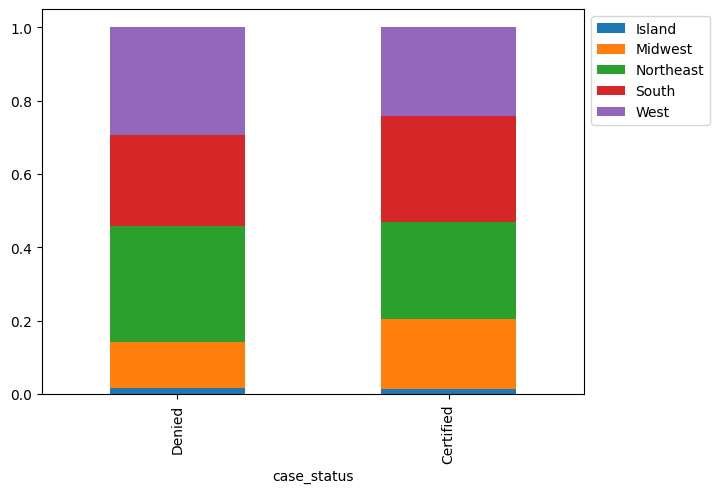

unit_of_wage  Hour  Month  Week   Year    All
case_status                                  
All           2153     89   272  22933  25447
Certified      747     55   169  16030  17001
Denied        1406     34   103   6903   8446
------------------------------------------------------------------------------------------------------------------------


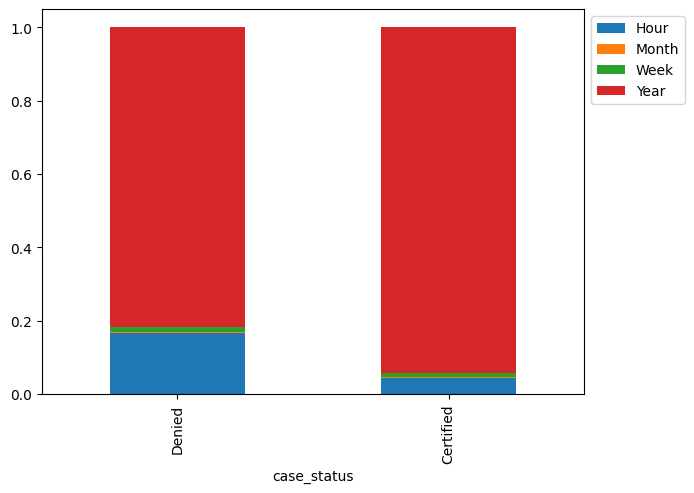

full_time_position     N      Y    All
case_status                           
All                 2706  22741  25447
Certified           1855  15146  17001
Denied               851   7595   8446
------------------------------------------------------------------------------------------------------------------------


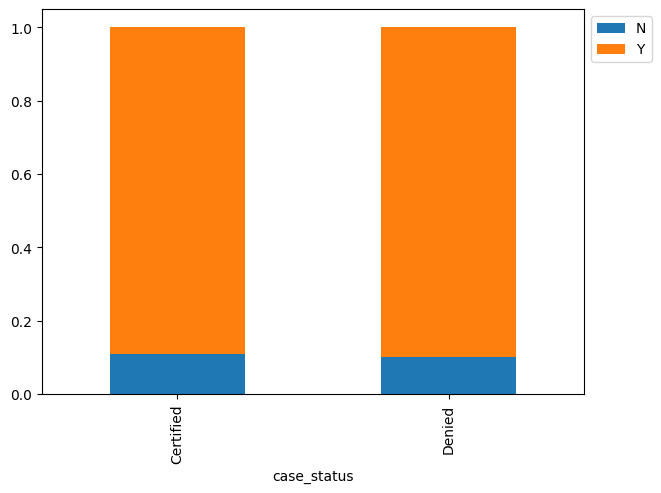

case_status  Certified  Denied    All
case_status                          
Denied               0    8446   8446
All              17001    8446  25447
Certified        17001       0  17001
------------------------------------------------------------------------------------------------------------------------


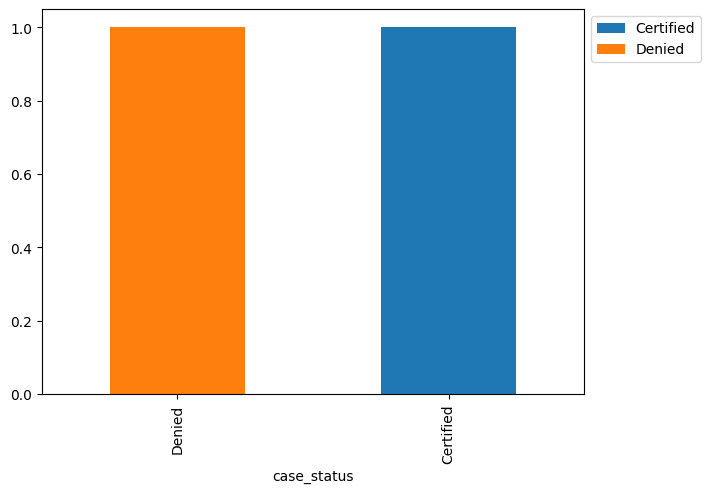

company_size  0-1000  1000-2000  2000-3000  3000-4000  4000+    All
case_status                                                        
All             6208       5915       4978       3548   4798  25447
Certified       4091       3878       3330       2341   3361  17001
Denied          2117       2037       1648       1207   1437   8446
------------------------------------------------------------------------------------------------------------------------


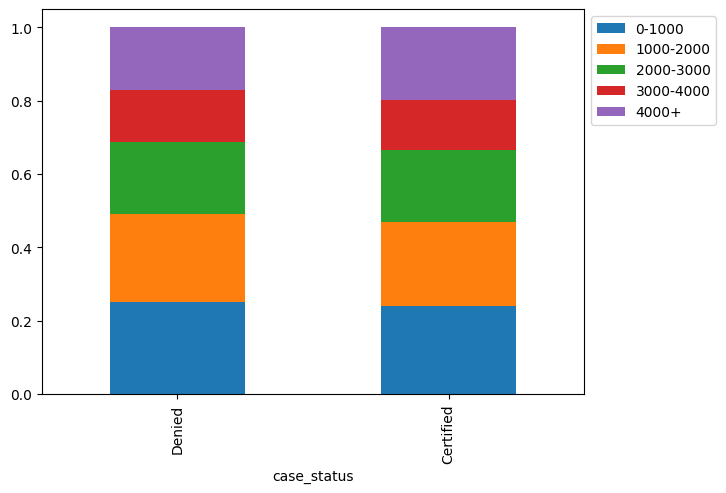

company_age   50+  30-50  20-30  10-20  0-10    All
case_status                                        
All          5106   3739   3386   8367  4849  25447
Certified    3385   2466   2226   5567  3357  17001
Denied       1721   1273   1160   2800  1492   8446
------------------------------------------------------------------------------------------------------------------------


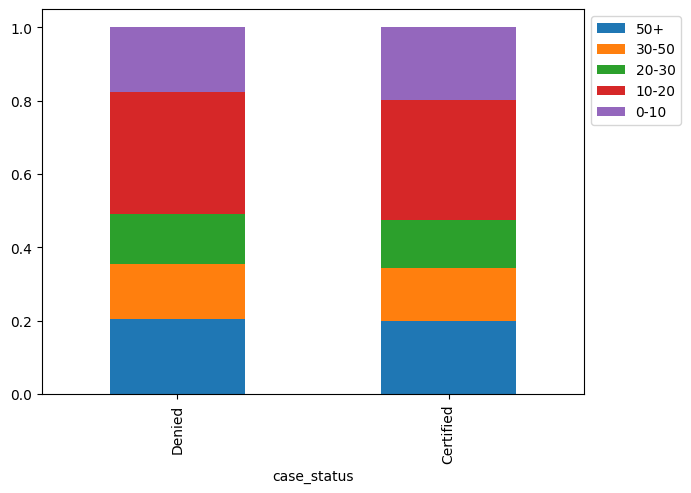

In [31]:
# Bivariate Analysis:
# Select all categorical columns from the DataFrame - df_cleaned.
categorical_columns = df_cleaned.select_dtypes(include=['category']).columns

# Loop over each categorical column and plot its relationship with 'case_status'.
for col in categorical_columns:
    stacked_barplot(df_cleaned, "case_status", col)

##### **Let's deep dive each important feature which might have an impact on visa certification.**

#### Those with higher education may want to travel abroad for a well-paid job. Let's find out if education has any impact on visa certification

In [32]:
#Proportional Analysis of certification likelihood varies across education levels
df_cleaned.groupby('education_of_employee')['case_status'].value_counts(normalize=True)

education_of_employee  case_status
Bachelor's             Certified      0.622505
                       Denied         0.377495
Doctorate              Certified      0.872545
                       Denied         0.127455
High School            Denied         0.659251
                       Certified      0.340749
Master's               Certified      0.786219
                       Denied         0.213781
Name: proportion, dtype: float64

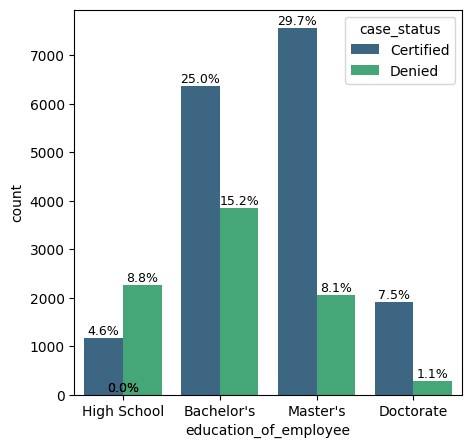

In [33]:
#create a plot of the data above, that helps to show, which education levels have higher certification rates
labeled_barplot(df_cleaned,'education_of_employee','case_status', order=["High School","Bachelor's","Master's","Doctorate"], perc=True)

#### Observations on above bar plot

#### **Certification Trends Across Education Levels**

#### Master's Degree holders is the largest group with certified cases, accounting for approximately 29.7% of the total applications.

#### Bachelor's Degree Holders is the second-largest group for certified cases (25%) but also has the highest proportion of denied cases (15.2%).

#### Doctorate Degree Holders is a smaller group overall but with a high certification success rate. 7.5% of applications are Certified, and only 1.1% are Denied

#### High School Education has the lowest certification rate at 4.6% and notably no denied cases recorded in the plot




#### Lets' similarly check for the continents and find out how the visa status vary across different continents.

In [34]:
#group data by continent and count the numbers of each case_status for each category
df_cleaned.groupby('continent')['case_status'].value_counts(normalize=True)

continent      case_status
Africa         Certified      0.720000
               Denied         0.280000
Asia           Certified      0.653266
               Denied         0.346734
Europe         Certified      0.792326
               Denied         0.207674
North America  Certified      0.619714
               Denied         0.380286
Oceania        Certified      0.635417
               Denied         0.364583
South America  Certified      0.578143
               Denied         0.421857
Name: proportion, dtype: float64

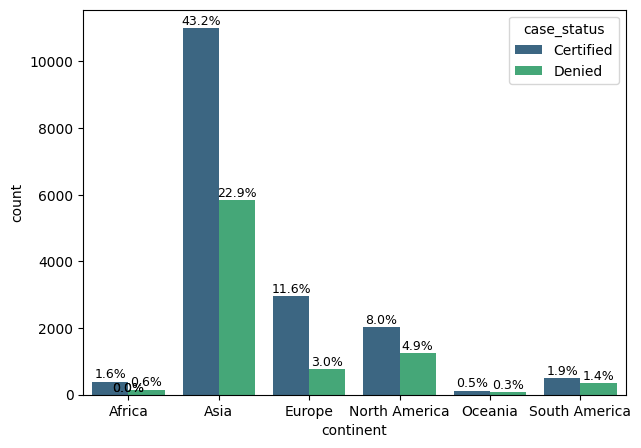

In [35]:
#create a plot for the above question
labeled_barplot(df_cleaned,'continent','case_status', order=None, perc=True)

#### Observations from above Bar Plot:

#### Case Status Distribution by Continent
#### Asia has the highest number of cases overall, with 43.2% Certified and 22.9% Denied

#### Europe has 11.6% Certified and 3.0% Denied cases

#### North America shows 8.0% Certified and 4.9% Denied cases

#### Africa contributes 1.6% Certified and 0.6% Denied cases, making it one of the smaller contributors

#### Oceania has the smallest representation, with 0.5% Certified and 0.3% Denied cases
#### South America has 1.9% Certified and 1.4% Denied cases

#### **Certification and Denial Patterns**

#### Asias large volume of cases and relatively high Denied proportion suggests that applicants from this region are driving much of the dataset's dynamics.


#### Experienced professionals might look abroad for opportunities to improve their lifestyles and career development. Let's see if having work experience has any influence over visa certification

In [36]:
#To compare the likelihood (or proportions) of certification between candidates with and without job experience, it’s beneficial to see the percentages rather than just raw counts.
df_cleaned.groupby('has_job_experience')['case_status'].value_counts(normalize=True)

has_job_experience  case_status
N                   Certified      0.561486
                    Denied         0.438514
Y                   Certified      0.744961
                    Denied         0.255039
Name: proportion, dtype: float64

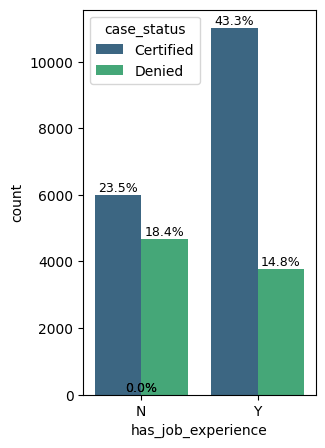

In [37]:
#create a plot of the data above question # 3:
labeled_barplot(df_cleaned,'has_job_experience','case_status', order=None, perc=True)

#### Observations from above bar plot:
#### **Certification Rates by Job Experience**

#### A significant proportion of individuals with job experience are Certified, accounting for approximately 43.3% (around 11,000 cases). Denied cases for this group are much lower, making up only 14.8% (around 3,750 cases).

#### A smaller proportion of individuals without job experience are Certified, about 23.5% (around 6,000 cases).Denied cases for this group are relatively higher, accounting for 18.4% (approximately 4,500 cases)

#### **Certified cases for applicants with job experience (Y) are almost 2x higher than those without job experience (N).**


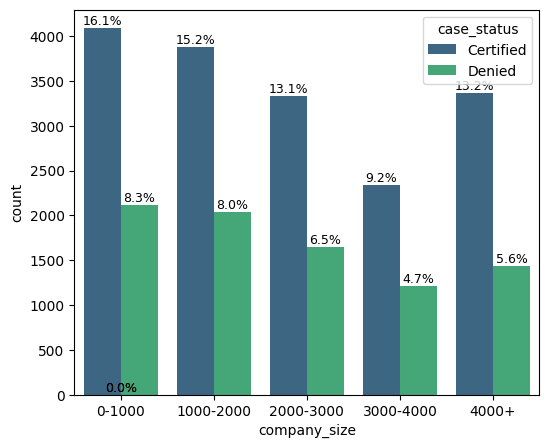

In [38]:
#create a barplot of size of the company that an applicant is applying for with the corresponding percent of approved and denied cases for each
labeled_barplot(df_cleaned,'company_size','case_status',perc=True,order=None)

#### Observations:
#### Company size does not exhibit a simple linear trend with certification outcomes. Instead, while very small and very large companies show strong certification rates, mid-sized companies (especially in the 3000–4000 range) experience relatively lower certification percentages and higher denial proportions.

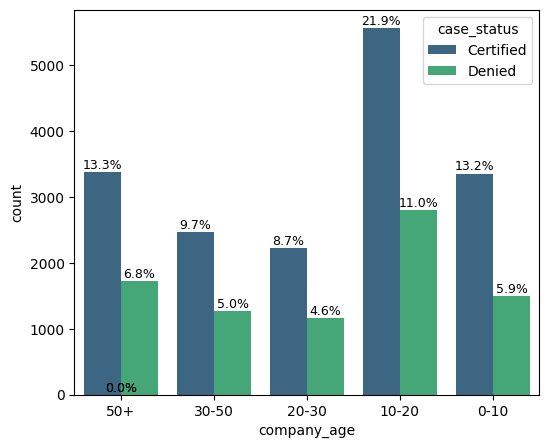

In [39]:
#create a barplot of size of the company that an applicant is applying for with the corresponding percent of approved and denied cases for each
labeled_barplot(df_cleaned,'company_age','case_status',perc=True,order=None)

#### Observations:

#### Companies having 10-20 years age are having highest visa certifications then other age group companies.

#### Checking if the prevailing wage is similar across all the regions of the US

#### **First we have to make all wages units to an "annual basis". This standardization helps to compare different wages.**

#### for this following helper function is created.



In [40]:
def convert_to_annual(wage, unit):
    """
    Converts the given wage value to an annual wage.

    Assumptions:
      - Hourly wage: multiplied by 2080 (40 hours/week * 52 weeks/year)
      - Weekly wage: multiplied by 52
      - Monthly wage: multiplied by 12
      - Annual wage: remains the same
    """
    unit = unit.lower()
    if unit in ['hour', 'hourly']:
        return wage * 2080
    elif unit in ['week', 'weekly']:
        return wage * 52
    elif unit in ['month', 'monthly']:
        return wage * 12
    elif unit in ['year', 'annually', 'annual']:
        return wage
    else:
        # If the unit is not recognized, just return the wage value
        return wage



In [41]:
# Apply the conversion function row-wise to create a new column 'annual_wage'
df_cleaned['annual_wage'] = df_cleaned.apply(lambda row: convert_to_annual(row['prevailing_wage'], row['unit_of_wage']), axis=1)

In [42]:
#Check if annual_wage column is created for the data frame df_cleaned
df_cleaned.head()

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status,company_size,company_age,annual_wage
0,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied,4000+,0-10,1231782.032
1,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified,2000-3000,10-20,83425.650
2,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied,4000+,0-10,122996.860
3,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied,0-1000,50+,83434.030
4,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified,1000-2000,10-20,149907.390


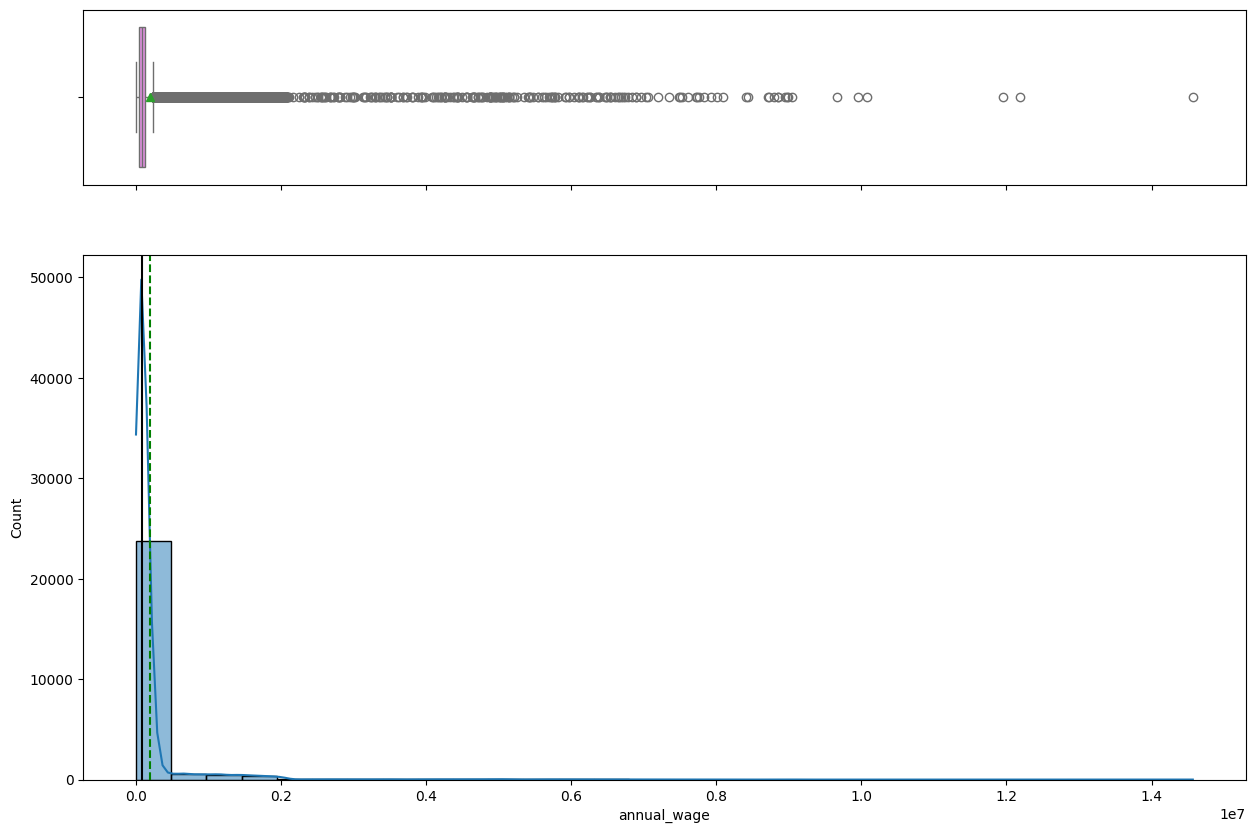

In [43]:
##Visualize the Annualized Wage Across Regions using new column annual_wage
histogram_boxplot(data=df_cleaned, feature='annual_wage', figsize=(15,10), kde=True, bins=30)

#### Above Box Plot is not giving a clear picture, so I created the following boxplot to Annualized Prevailing Wage by Region of Employment

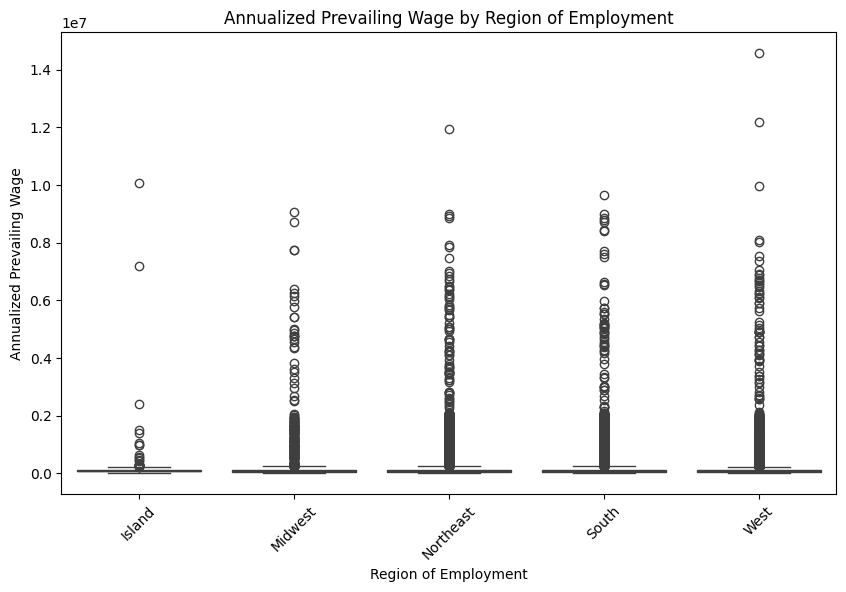

In [44]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='region_of_employment', y='annual_wage', data=df_cleaned)
plt.title("Annualized Prevailing Wage by Region of Employment")
plt.xlabel("Region of Employment")
plt.ylabel("Annualized Prevailing Wage")
plt.xticks(rotation=45)
plt.show()


#### Observations:

#### 1. Median wages are fairly similar for all regions (Island, Midwest, Northeast, South, and West)

#### 2. Since the medians and IQRs are alike, we may conclude that the overall level of prevailing wages is similar across these regions for the majority of cases.

#### The US government has established a prevailing wage to protect local talent and foreign workers. Let's analyze the data and see if the visa status changes with the prevailing wage

In [45]:
# As a first step, let's check summary statistics by Visa Outcome
stats_by_status = df_cleaned.groupby('case_status')['annual_wage'].describe()
stats_by_status

,count,mean,std,min,25%,50%,75%,max
case_status,,,,,,,,
Certified,17001.0,162790.830957,543823.050105,100.00,44831.2,79372.810,117918.840,14569149.4
Denied,8446.0,267255.819572,638063.562526,153.11,52211.1,91842.155,143965.765,11957436.4


In [46]:
# Using Statistical Testing:

from scipy.stats import ttest_ind

# Separate the wage data based on visa status
certified_wages = df_cleaned[df_cleaned['case_status'] == 'Certified']['annual_wage']
denied_wages    = df_cleaned[df_cleaned['case_status'] == 'Denied']['annual_wage']

t_stat, p_val = ttest_ind(certified_wages, denied_wages, nan_policy='omit')
print("t-statistic:", round(t_stat,4))
print("p-value:", round(p_val,4))

t-statistic: -13.6045
p-value: 0.0


#### Observations

##### The fact that combined metrics (mean, median, and quartile values) are higher for Denied cases suggests that excessively high wage offers might trigger additional questions during the visa review process


#### The prevailing wage has different units (Hourly, Weekly, etc). Let's find out if it has any impact on visa applications getting certified.

#### **Conclusions**
#### **Above statistical observations suggest that wage level is an important factor in the visa decision process, with denied applications generally coming with higher wage offers.**

#### **The p-value of 0.0  tells us that the probability of observing a difference in means by random chance is virtually zero.**

#### **The negative t-statistic (-13.6045) indicates the direction of the difference when comparing the two groups - Certified wages (first group) vs Denied wages (second group), a negative value means that the mean wage for the Certified group is significantly lower than the mean wage for the Denied group.**

#### **This result suggests that applicants with lower prevailing (annualized) wages are more likely to be Certified, whereas those with higher wages are more likely to be Denied, or vice versa which we have to investigate further**

## Data Pre-processing

#### Summary of int64 variables.

In [47]:
#provide summary statistics of all int64 variables
df_cleaned.describe(include = ['int64']).T

,count,mean,std,min,25%,50%,75%,max
no_of_employees,25447.0,5674.415334,22891.842245,12.0,1025.0,2112.0,3506.5,602069.0
yr_of_estab,25447.0,1979.394506,42.385932,1800.0,1976.0,1997.0,2005.0,2016.0


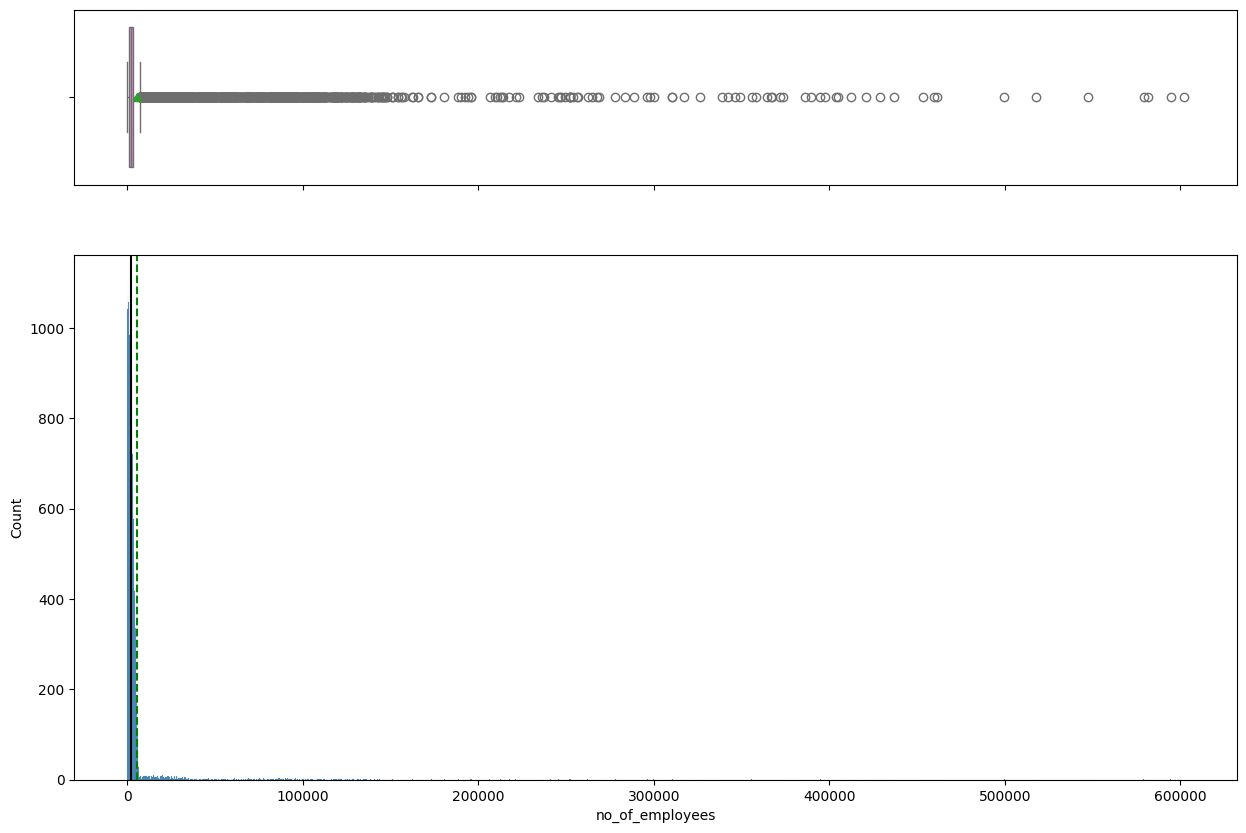

In [48]:
#provide histogram and boxplots
histogram_boxplot(df_cleaned, 'no_of_employees')

#### The data and graphs above, indicate the distribution of companies by number of employee is heavily right skewed, but without any outlier values that require further investigation or treatment.

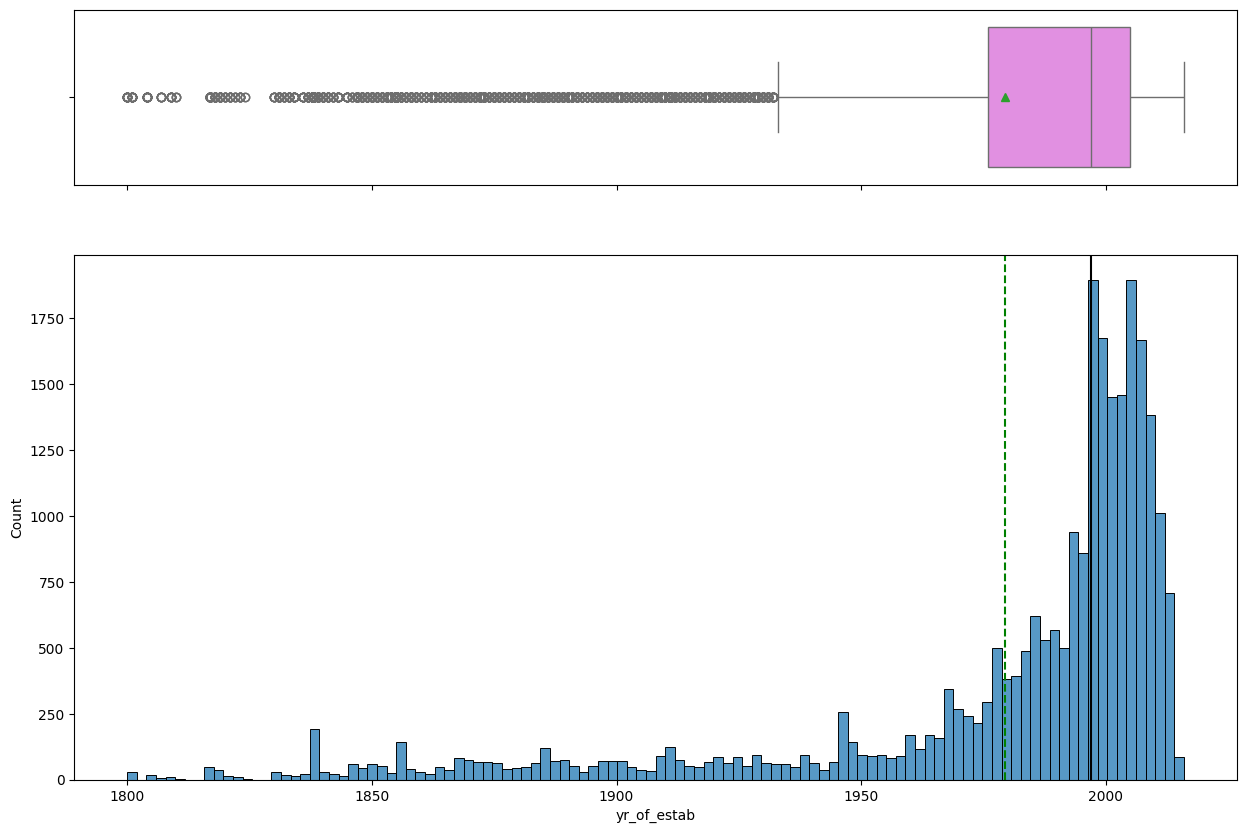

In [49]:
histogram_boxplot(df_cleaned, 'yr_of_estab')

#### The data and graphs above, indicate the distribution of companies by year of establishment (i.e., founding) is heavily left skewed, but without any outlier values which require further investigation or treatment.

#### Summary of float64 variables

In [50]:
#provide summary statistics of all float64 variables
df_cleaned.describe(include = ['float64']).T

,count,mean,std,min,25%,50%,75%,max
prevailing_wage,25447.0,74468.281479,52822.177370,2.1367,34039.210,70312.5,107739.505,319210.27
annual_wage,25447.0,197463.338280,578893.001653,100.0000,47137.505,82838.4,124826.630,14569149.40


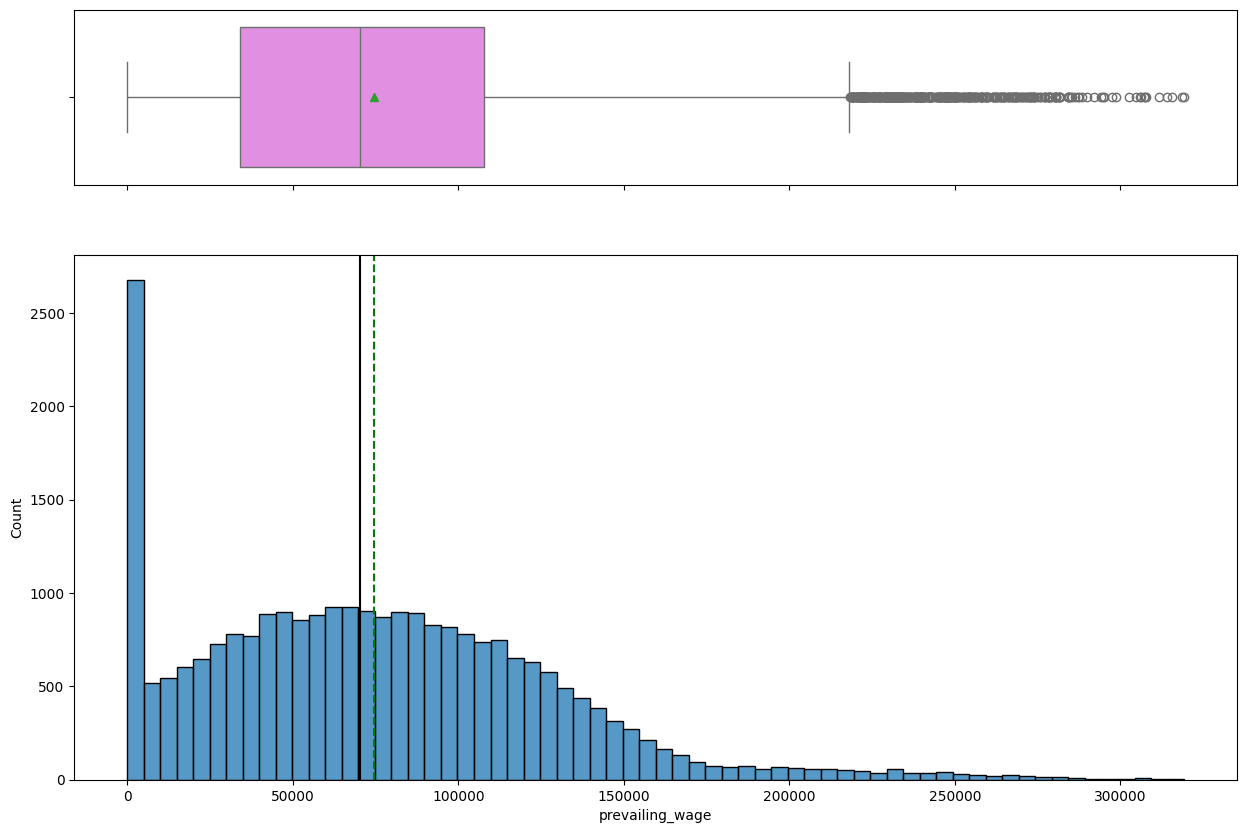

In [51]:
#provide histogram and boxplot
histogram_boxplot(df_cleaned,'prevailing_wage')

### Outlier Check

In [52]:
df_cleaned.columns

Index(['continent', 'education_of_employee', 'has_job_experience',
       'requires_job_training', 'no_of_employees', 'yr_of_estab',
       'region_of_employment', 'prevailing_wage', 'unit_of_wage',
       'full_time_position', 'case_status', 'company_size', 'company_age',
       'annual_wage'],
      dtype='object')

In [53]:
df_cleaned.head()

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status,company_size,company_age,annual_wage
0,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied,4000+,0-10,1231782.032
1,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified,2000-3000,10-20,83425.650
2,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied,4000+,0-10,122996.860
3,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied,0-1000,50+,83434.030
4,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified,1000-2000,10-20,149907.390


In [54]:
#drop the int_64 columns from the dataframe, since this information is captured through the features engineered above
#df_cleaned.drop(labels=['no_of_employees','yr_of_estab'], axis=1, inplace=True)
df_model = df_cleaned.drop(labels=['no_of_employees','yr_of_estab'], axis=1, inplace=True)
#df_cleaned.drop(labels=['no_of_employees','yr_of_estab'], axis=1, inplace=True)


In [55]:
#confirm if both columns are dropped
df_cleaned.head()

,continent,education_of_employee,has_job_experience,requires_job_training,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status,company_size,company_age,annual_wage
0,Asia,High School,N,N,West,592.2029,Hour,Y,Denied,4000+,0-10,1231782.032
1,Asia,Master's,Y,N,Northeast,83425.6500,Year,Y,Certified,2000-3000,10-20,83425.650
2,Asia,Bachelor's,N,Y,West,122996.8600,Year,Y,Denied,4000+,0-10,122996.860
3,Asia,Bachelor's,N,N,West,83434.0300,Year,Y,Denied,0-1000,50+,83434.030
4,Africa,Master's,Y,N,South,149907.3900,Year,Y,Certified,1000-2000,10-20,149907.390


#### Applying encoding for the target predictor

#### Encoding Certified as 1 and Denied as 0.

In [56]:
#Encoding Certified as 1 and Denied as 0
df_cleaned["case_status"] = df_cleaned["case_status"].apply(lambda x: 1 if x == "Certified" else 0)

In [57]:
#Check if encoding is happened correctly
df_cleaned["case_status"].value_counts()

,count
case_status,
1,17001
0,8446


#### Spliting the data

In [58]:
#create a dataframe of the predictor feature columns
X = df_cleaned.drop('case_status',axis=1)
#create a datafrane of the predicted class
y = df_cleaned["case_status"]

In [59]:
# Splitting data into training, validation and test set:
# first we split data into 2 parts, say temporary and test

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1, stratify=y
)

# then we split the temporary set into train and validation

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=1, stratify=y_temp
)
print(X_train.shape, X_val.shape, X_test.shape)

(15267, 11) (5090, 11) (5090, 11)


In [60]:
print("Number of rows in train data =", X_train.shape[0])
print("Number of rows in validation data =", X_val.shape[0])
print("Number of rows in test data =", X_test.shape[0])

Number of rows in train data = 15267
Number of rows in validation data = 5090
Number of rows in test data = 5090


In [61]:
print(X_train.shape, X_val.shape, X_test.shape)

(15267, 11) (5090, 11) (5090, 11)


In [62]:
df_cleaned.isnull().sum()

,0
continent,0
education_of_employee,0
has_job_experience,0
requires_job_training,0
region_of_employment,0
prevailing_wage,0
unit_of_wage,0
full_time_position,0
case_status,0
company_size,0


### No Missing values

#### Creating Dummy Variables

In [63]:
X_train = pd.get_dummies(X_train, drop_first=True)
X_train = X_train.astype(float)

X_val = pd.get_dummies(X_val, drop_first=True)
X_val = X_val.astype(float)

X_test = pd.get_dummies(X_test, drop_first=True)
X_test = X_test.astype(float)

print(X_train.shape, X_val.shape, X_test.shape)

(15267, 28) (5090, 28) (5090, 28)


After encoding there are 28 columns.

### Data Preparation for modeling

## Model Building

### Model Evaluation Criterion

In [64]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn


def model_performance_classification_sklearn(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )

    return df_perf

In [65]:
def confusion_matrix_sklearn(model, predictors, target):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    y_pred = model.predict(predictors)
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

### Model building with original data

In [66]:
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Bagging", BaggingClassifier(estimator=DecisionTreeClassifier(random_state=1, class_weight='balanced'), random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1, class_weight='balanced')))
models.append(("GBM", GradientBoostingClassifier(random_state=1)))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models.append(("dtree", DecisionTreeClassifier(random_state=1, class_weight='balanced')))

print("\nTraining Performance:\n")
for name, model in models:
    model.fit(X_train, y_train)
    scores = recall_score(y_train, model.predict(X_train))
    print("{}: {}".format(name, scores))

print("\nValidation Performance:\n")
for name, model in models:
    model.fit(X_train, y_train)
    scores_val = recall_score(y_val, model.predict(X_val))
    print("{}: {}".format(name, scores_val))


Training Performance:

Bagging: 0.9816648691048142
Random forest: 1.0
GBM: 0.8749877438964604
Adaboost: 0.9040101970781449
dtree: 1.0

Validation Performance:

Bagging: 0.7806527491914143
Random forest: 0.818582769773596
GBM: 0.8762128785651279
Adaboost: 0.9064980887974126
dtree: 0.7430167597765364


In [67]:
print("\nTraining and Validation Performance Difference:\n")

for name, model in models:
    model.fit(X_train, y_train)
    scores_train = recall_score(y_train, model.predict(X_train))
    scores_val = recall_score(y_val, model.predict(X_val))
    difference1 = scores_train - scores_val
    print("{}: Training Score: {:.4f}, Validation Score: {:.4f}, Difference: {:.4f}".format(name, scores_train, scores_val, difference1))


Training and Validation Performance Difference:

Bagging: Training Score: 0.9817, Validation Score: 0.7807, Difference: 0.2010
Random forest: Training Score: 1.0000, Validation Score: 0.8186, Difference: 0.1814
GBM: Training Score: 0.8750, Validation Score: 0.8762, Difference: -0.0012
Adaboost: Training Score: 0.9040, Validation Score: 0.9065, Difference: -0.0025
dtree: Training Score: 1.0000, Validation Score: 0.7430, Difference: 0.2570


#### Observations:


**BaggingClassifier**:
    
* Difference b/w Training & Validation score  : 0.2010
* Interpretation: Very high performance on training data with a large gap (about 20 percentage points) to the validation score. This suggests the model is overfitting—capturing noise in the training set that doesn't generalize well

**Random Forest**

* Difference b/w Training & Validation score  :: 0.1814

* Interpretation: Perfect training performance, but a significant drop in validation performance. The gap (nearly 18 percentage points) again indicates overfitting even though the validation score is somewhat better than Bagging

**Gradient Boosting Machine (GBM)**
* Difference b/w Training & Validation score  :: -0.0012

* Interpretation: The training and validation scores are almost identical, which shows excellent generalization. However, the absolute performance levels are around 87–88%, which is solid but lower than some alternatives

**AdaBoost**
* Difference b/w Training & Validation score  :: -0.0025

* Interpretation: Very similar training and validation scores with an almost zero gap. Not only does this model generalize very well, but it also achieves the highest validation score (90.65%) among all models.

**Decision Tree (dtree)**
* Difference b/w Training & Validation score  :: 0.2570
* Interpretation: While the tree perfectly fits the training data, it performs poorly on validation, with a large gap (about 26 percentage points), indicating severe overfitting

**Context Conclusion:**

**Given its high validation score and minimal overfitting, AdaBoost is the preferred model.**


#### Defining scorer to be used for cross-validation and hyperparameter tuning

### Model Building with oversampled data

In [68]:
# To oversample and undersample data
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

In [69]:
print("Before Oversampling, counts of label 'Yes (Certified)': {}".format(sum(y_train == 1)))
print("Before Oversampling, counts of label 'No (Denied)': {} \n".format(sum(y_train == 0)))

sm = SMOTE(
    sampling_strategy=1, k_neighbors=5, random_state=1
)  # Synthetic Minority Over Sampling Technique
X_train_over, y_train_over = sm.fit_resample(X_train, y_train)


print("After Oversampling, counts of label 'Yes (Certified)': {}".format(sum(y_train_over == 1)))
print("After Oversampling, counts of label 'No (Denied)': {} \n".format(sum(y_train_over == 0)))


print("After Oversampling, the shape of train_X: {}".format(X_train_over.shape))
print("After Oversampling, the shape of train_y: {} \n".format(y_train_over.shape))

Before Oversampling, counts of label 'Yes (Certified)': 10199
Before Oversampling, counts of label 'No (Denied)': 5068 

After Oversampling, counts of label 'Yes (Certified)': 10199
After Oversampling, counts of label 'No (Denied)': 10199 

After Oversampling, the shape of train_X: (20398, 28)
After Oversampling, the shape of train_y: (20398,) 



#### **Model Building with oversampled data**

In [70]:
# Model Building with oversampled data

models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Bagging", BaggingClassifier(estimator=DecisionTreeClassifier(random_state=1, class_weight='balanced'), random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1, class_weight='balanced')))
models.append(("GBM", GradientBoostingClassifier(random_state=1)))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models.append(("dtree", DecisionTreeClassifier(random_state=1, class_weight='balanced')))

print("\n" "Training Performance:" "\n")
for name, model in models:
    model.fit(X_train_over, y_train_over)
    scores = recall_score(y_train_over, model.predict(X_train_over))
    print("{}: {}".format(name, scores))

print("\n" "Validation Performance:" "\n")

for name, model in models:
    model.fit(X_train_over, y_train_over)
    scores = recall_score(y_val, model.predict(X_val))
    print("{}: {}".format(name, scores))


Training Performance:

Bagging: 0.9806843808216492
Random forest: 1.0
GBM: 0.8668496911461908
Adaboost: 0.8373369938229238
dtree: 1.0

Validation Performance:

Bagging: 0.766539253160835
Random forest: 0.8147603645986474
GBM: 0.8709203175536607
Adaboost: 0.8421052631578947
dtree: 0.7424286974419289


In [71]:
print("\nTraining and Validation Performance Difference - oversampled:\n")

for name, model in models:
    model.fit(X_train_over, y_train_over)
    scores_train = recall_score(y_train_over, model.predict(X_train_over))
    scores_val = recall_score(y_val, model.predict(X_val))
    difference2 = scores_train - scores_val
    print("{}: Training Score: {:.4f}, Validation Score: {:.4f}, Difference: {:.4f}".format(name, scores_train, scores_val, difference2))


Training and Validation Performance Difference - oversampled:

Bagging: Training Score: 0.9807, Validation Score: 0.7665, Difference: 0.2141
Random forest: Training Score: 1.0000, Validation Score: 0.8148, Difference: 0.1852
GBM: Training Score: 0.8668, Validation Score: 0.8709, Difference: -0.0041
Adaboost: Training Score: 0.8373, Validation Score: 0.8421, Difference: -0.0048
dtree: Training Score: 1.0000, Validation Score: 0.7424, Difference: 0.2576


#### **Observations**
#### **Bagging**
* Interpretation: The model performs extremely well on training data but drops significantly on validation data—indicative of overfitting

#### **Random Forest:**

* Interpretation: Perfect training performance and a substantial drop in validation performance shows overfitting, although its validation performance is a bit better than Bagging.

#### **Gradient Boosting Machine (GBM):**

* Interpretation: The training and validation scores are nearly identical, suggesting excellent generalization. The validation performance is around 87.1%

#### **AdaBoost**

* Interpretation: Like GBM, AdaBoost shows almost no gap between training and validation performance, which means it generalizes very well. Its validation score is about 84.2%

#### **Decision Tree:**

* Interpretation: A classic case of overfitting—perfect on training data with very poor performance on validation

#### **Conclusion on Model Performances for oversampled data**

#### **Gradient Boosting Machine (GBM) is working the best on oversampled data reason being: It achieves the highest validation score (87.1%) among the models that generalize well**.

### Model Building with undersampled data

In [72]:
rus = RandomUnderSampler(random_state=1)
X_train_un, y_train_un = rus.fit_resample(X_train, y_train)

In [73]:
print("Before Under Sampling, counts of label 'Yes (Certified)': {}".format(sum(y_train == 1)))
print("Before Under Sampling, counts of label 'No (Denied)': {} \n".format(sum(y_train == 0)))

print("After Under Sampling, counts of label 'Yes (Certified)': {}".format(sum(y_train_un == 1)))
print("After Under Sampling, counts of label 'No (Denied)': {} \n".format(sum(y_train_un == 0)))

print("After Under Sampling, the shape of train_X: {}".format(X_train_un.shape))
print("After Under Sampling, the shape of train_y: {} \n".format(y_train_un.shape))

Before Under Sampling, counts of label 'Yes (Certified)': 10199
Before Under Sampling, counts of label 'No (Denied)': 5068 

After Under Sampling, counts of label 'Yes (Certified)': 5068
After Under Sampling, counts of label 'No (Denied)': 5068 

After Under Sampling, the shape of train_X: (10136, 28)
After Under Sampling, the shape of train_y: (10136,) 



In [74]:
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Bagging", BaggingClassifier(estimator=DecisionTreeClassifier(random_state=1, class_weight='balanced'), random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1, class_weight='balanced')))
models.append(("GBM", GradientBoostingClassifier(random_state=1)))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models.append(("dtree", DecisionTreeClassifier(random_state=1, class_weight='balanced')))


print("\n" "Training Performance:" "\n")
for name, model in models:
    model.fit(X_train_un, y_train_un)
    scores = recall_score(y_train_un, model.predict(X_train_un))
    print("{}: {}".format(name, scores))

print("\n" "Validation Performance:" "\n")

for name, model in models:
    model.fit(X_train_un, y_train_un)
    scores = recall_score(y_val, model.predict(X_val))
    print("{}: {}".format(name, scores))


Training Performance:

Bagging: 0.9599447513812155
Random forest: 0.999605367008682
GBM: 0.738950276243094
Adaboost: 0.7409234411996843
dtree: 1.0

Validation Performance:

Bagging: 0.6089385474860335
Random forest: 0.6712731549544252
GBM: 0.7286092325786533
Adaboost: 0.7441928844457513
dtree: 0.6318729785357248


In [75]:
print("\nTraining and Validation Performance Difference - Undersampled:\n")

for name, model in models:
    model.fit(X_train_un, y_train_un)
    scores_train = recall_score(y_train_un, model.predict(X_train_un))
    scores_val = recall_score(y_val, model.predict(X_val))
    difference3 = scores_train - scores_val
    print("{}: Training Score: {:.4f}, Validation Score: {:.4f}, Difference: {:.4f}".format(name, scores_train, scores_val, difference3))


Training and Validation Performance Difference - Undersampled:

Bagging: Training Score: 0.9599, Validation Score: 0.6089, Difference: 0.3510
Random forest: Training Score: 0.9996, Validation Score: 0.6713, Difference: 0.3283
GBM: Training Score: 0.7390, Validation Score: 0.7286, Difference: 0.0103
Adaboost: Training Score: 0.7409, Validation Score: 0.7442, Difference: -0.0033
dtree: Training Score: 1.0000, Validation Score: 0.6319, Difference: 0.3681


#### Observations

**BaggingClassifier**

* **Observation**: Although training performance is high (96%), the validation score drops considerably (61%). This large gap (35%) indicates significant overfitting.

**Random Forest**

* **Observation**: Again, the model achieves nearly perfect performance on the training set but the validation score is only about 67%. The high gap (33%) shows overfitting.

**Gradient Boosting Machine (GBM)**

* **Observation**: The training and validation scores are very close (around 73–74%), meaning the model generalizes well without overfitting. However, the absolute performance is somewhat lower compared to the overfitting models.

**AdaBoost**

* **Observation**: AdaBoost shows almost identical performance between training and validation (approximately 74%). The nearly zero difference indicates excellent generalization, and its validation score is slightly higher than GBMs

**Decision Tree (dtree)**

**Observation**: The tree perfectly fits the training data but performs poorly on validation (63%), with the largest gap (36.8%), making it the most overfitted among the compared models.

#### Conclusion on Model Performance's for undersampled data:

#### **GBM and AdaBoost both have modest training scores (around 74%) that match almost exactly with their validation scores (difference close to zero). This indicates that these models are not overfitting and generalize much better to unseen data.**


## Hyperparameter Tuning

### Tuning AdaBoost using oversampled data

In [76]:
%%time

# defining model
Model = AdaBoostClassifier(random_state=1)

# Parameter grid to pass in RandomSearchCV
param_grid = {
    "n_estimators": np.arange(10, 40, 10),
    "learning_rate": [0.1, 0.01, 0.2, 0.05, 1],
    "estimator": [
        DecisionTreeClassifier(max_depth=1, random_state=1),
        DecisionTreeClassifier(max_depth=2, random_state=1),
        DecisionTreeClassifier(max_depth=3, random_state=1),
    ],
}

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.recall_score)

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid, n_jobs = -1, n_iter=50, scoring=scorer, cv=5, random_state=1)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train_over, y_train_over)

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'n_estimators': np.int64(10), 'learning_rate': 0.01, 'estimator': DecisionTreeClassifier(max_depth=1, random_state=1)} with CV score=0.9314642414101492:
CPU times: user 3.29 s, sys: 589 ms, total: 3.88 s
Wall time: 2min 11s


In [82]:
tuned_adb = AdaBoostClassifier(
    random_state=1,
    n_estimators=20,
    learning_rate=0.1,
    estimator=DecisionTreeClassifier(max_depth=2, random_state=1),
)
tuned_adb.fit(X_train_over, y_train_over)

AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=2,
                                                    random_state=1),
                   learning_rate=0.1, n_estimators=20, random_state=1)

In [83]:
# Checking model's performance on training set
adb_train = model_performance_classification_sklearn(tuned_adb, X_train_over, y_train_over)
adb_train

,Accuracy,Recall,Precision,F1
0,0.735709,0.753113,0.727781,0.74023


In [84]:
# Checking model's performance on validation set
adb_val = model_performance_classification_sklearn(tuned_adb, X_val, y_val)
adb_val

,Accuracy,Recall,Precision,F1
0,0.688016,0.754484,0.773124,0.76369


### Tuning Random forest using undersampled data

In [85]:
# Define the model
model = RandomForestClassifier(random_state=1, class_weight='balanced')

# Parameter grid for RandomForestClassifier
param_grid = {
    "n_estimators": np.arange(10, 40, 10),       # e.g., 10, 20, 30 trees
    "max_depth": [None, 3, 5, 10],                # None means no max depth constraint
    "min_samples_split": [2, 4, 6],               # minimum samples required to split
    "max_features": ["auto", "sqrt", "log2"]      # number of features to consider for the best split
}

# Define the scoring function
scorer = metrics.make_scorer(metrics.recall_score)

# Set up RandomizedSearchCV
randomized_cv = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_grid,
    n_jobs=-1,
    n_iter=50,
    scoring=scorer,
    cv=5,
    random_state=1
)

# Fit RandomizedSearchCV on undersampled training data
randomized_cv.fit(X_train_un, y_train_un)

# Display the best parameters found and the corresponding CV score
print("Best parameters are {} with CV score={}."
      .format(randomized_cv.best_params_, randomized_cv.best_score_))

Best parameters are {'n_estimators': np.int64(30), 'min_samples_split': 6, 'max_features': 'log2', 'max_depth': 3} with CV score=0.8086008127089455.


In [86]:
tuned_rf = RandomForestClassifier(
    n_estimators=20,          # Number of trees in the forest
    max_depth=2,              # Maximum depth of each decision tree
    random_state=1,           # For reproducibility
    class_weight='balanced'   # to handle class imbalance
)

# Fit the tuned Random Forest classifier on your oversampled training data
tuned_rf.fit(X_train_un, y_train_un)

RandomForestClassifier(class_weight='balanced', max_depth=2, n_estimators=20,
                       random_state=1)

In [87]:
# Checking model's performance on training set
rfc_train = model_performance_classification_sklearn(tuned_rf, X_train_un, y_train_un)
rfc_train

,Accuracy,Recall,Precision,F1
0,0.651638,0.872928,0.605116,0.714759


In [88]:
# Checking model's performance on validation set
rfc_val = model_performance_classification_sklearn(tuned_rf, X_val, y_val)
rfc_val

,Accuracy,Recall,Precision,F1
0,0.723969,0.87239,0.753428,0.808557


### Tuning with Gradient boosting with oversampled data

In [89]:
%%time

#Creating pipeline
Model = GradientBoostingClassifier(random_state=1)

#Parameter grid to pass in RandomSearchCV
param_grid = {
    "init": [AdaBoostClassifier(random_state=1),DecisionTreeClassifier(random_state=1)],
    "n_estimators": np.arange(125,175,25),
    "learning_rate": [0.01, 0.2, 0.05, 1],
    "subsample":[0.8,0.9,1],
    "max_features":[0.5,0.7,1],
}

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.recall_score)

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid, n_iter=50, scoring=scorer, cv=5, random_state=1, n_jobs = -1)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train_over,y_train_over)

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'subsample': 0.9, 'n_estimators': np.int64(150), 'max_features': 1, 'learning_rate': 0.01, 'init': AdaBoostClassifier(random_state=1)} with CV score=0.8755724643952725:
CPU times: user 8.81 s, sys: 1.25 s, total: 10.1 s
Wall time: 10min 49s


In [90]:
tuned_gbm1 = GradientBoostingClassifier(
    random_state=1,
    subsample=0.9,
    n_estimators=150,
    max_features=0.5,
    learning_rate=0.01,
    init=AdaBoostClassifier(random_state=1),
)
tuned_gbm1.fit(X_train_over, y_train_over)

GradientBoostingClassifier(init=AdaBoostClassifier(random_state=1),
                           learning_rate=0.01, max_features=0.5,
                           n_estimators=150, random_state=1, subsample=0.9)

In [91]:
# Checking model's performance on training set
gbm1_train = model_performance_classification_sklearn(
    tuned_gbm1, X_train_over, y_train_over
)
gbm1_train

,Accuracy,Recall,Precision,F1
0,0.792725,0.829591,0.772624,0.800095


In [92]:
# Checking model's performance on validation set
gbm1_val = model_performance_classification_sklearn(tuned_gbm1, X_val, y_val)
gbm1_val

,Accuracy,Recall,Precision,F1
0,0.738114,0.833284,0.787222,0.809599


### Tuning XGBoost using oversampled data

In [93]:
model = XGBClassifier(random_state=1, use_label_encoder=False, eval_metric='logloss')

# Define the parameter grid for tuning.
# Note: "colsample_bytree" in XGBoost is analogous to "max_features" in GBM.
param_grid = {
    "n_estimators": np.arange(125, 175, 25),         # e.g., 125, 150
    "learning_rate": [0.01, 0.2, 0.05, 1],
    "subsample": [0.8, 0.9, 1],
    "colsample_bytree": [0.5, 0.7, 1],                # fraction of features to consider
    "max_depth": [3, 4, 5]                            # maximum tree depth
}

# Define the scoring function (using recall as in your GBM tuning)
scorer = metrics.make_scorer(metrics.recall_score)

# Setup the randomized search using cross-validation.
randomized_cv = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_grid,
    n_iter=50,
    scoring=scorer,
    cv=5,
    random_state=1,
    n_jobs=-1
)

# Fit RandomizedSearchCV on the oversampled training data.
randomized_cv.fit(X_train_over, y_train_over)

# Print the best parameters and corresponding CV score.
print("Best parameters are {} with CV score={}"
      .format(randomized_cv.best_params_, randomized_cv.best_score_))

Best parameters are {'subsample': 0.8, 'n_estimators': np.int64(150), 'max_depth': 5, 'learning_rate': 0.05, 'colsample_bytree': 0.5} with CV score=0.8685132562097915


In [94]:
# Build the tuned XGBoost model using the best parameters.
tuned_xgb = XGBClassifier(
    random_state=1,
    n_estimators=randomized_cv.best_params_['n_estimators'],
    learning_rate=randomized_cv.best_params_['learning_rate'],
    subsample=randomized_cv.best_params_['subsample'],
    colsample_bytree=randomized_cv.best_params_['colsample_bytree'],
    max_depth=randomized_cv.best_params_['max_depth'],
    use_label_encoder=False,
    eval_metric='logloss'
)

# Fit the tuned model on the oversampled training data.
tuned_xgb.fit(X_train_over, y_train_over)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.5, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None,
              n_estimators=np.int64(150), n_jobs=None, num_parallel_tree=None,
              random_state=1, ...)

In [95]:
# Checking model's performance on training set
xgb_train = model_performance_classification_sklearn(
    tuned_xgb, X_train_over, y_train_over)
xgb_train

,Accuracy,Recall,Precision,F1
0,0.817041,0.870379,0.78648,0.826306


In [96]:
# Checking model's performance on validation set
xgb_val = model_performance_classification_sklearn(tuned_xgb, X_val, y_val)
xgb_val

,Accuracy,Recall,Precision,F1
0,0.751866,0.870626,0.782505,0.824217


**We have now tuned all the models, let's compare the performance of all tuned models and see which one is the best.**

## Model performance comparison and choosing the final model

In [110]:
# training performance comparison

models_train_comp_df = pd.concat(
    [
        adb_train.T,
        rfc_train.T,
        gbm1_train.T,
        xgb_train.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "AdaBoost trained with Oversampled data",
    "Random forest trained with Undersampled data",
    "Gradient boosting trained with Oversampled data",
    "XGBoost trained with Oversampled data"
]
print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,AdaBoost trained with Oversampled data,Random forest trained with Undersampled data,Gradient boosting trained with Oversampled data,XGBoost trained with Oversampled data
Accuracy,0.735709,0.651638,0.792725,0.817041
Recall,0.753113,0.872928,0.829591,0.870379
Precision,0.727781,0.605116,0.772624,0.786480
F1,0.740230,0.714759,0.800095,0.826306


In [111]:
# Validation performance comparison

models_train_comp_df = pd.concat(
    [
     adb_val.T,
     rfc_val.T,
     gbm1_val.T,
     xgb_val.T
     ], axis=1,
)
models_train_comp_df.columns = [
    "AdaBoost trained with Oversampled data",
    "Random forest trained with Undersampled data",
    "Gradient boosting trained with Oversampled data",
    "XGBoost trained with Oversampled data"
]
print("Validation performance comparison:")
models_train_comp_df

Validation performance comparison:


,AdaBoost trained with Oversampled data,Random forest trained with Undersampled data,Gradient boosting trained with Oversampled data,XGBoost trained with Oversampled data
Accuracy,0.688016,0.723969,0.738114,0.751866
Recall,0.754484,0.872390,0.833284,0.870626
Precision,0.773124,0.753428,0.787222,0.782505
F1,0.763690,0.808557,0.809599,0.824217


#### **Interpreting the Metrics**

* **Accuracy**:
This metric tells the overall percentage of correct predictions. Here, the AdaBoost with undersampled data (75.17%) is the highest.

* **Recall**:

Recall is crucial when we want to minimize false negatives (i.e., missing out on correctly identifying true positive cases). Both Random Forest (87.29%) and AdaBoost (Undersampled, 87.16%) have high recall, meaning they capture a large portion of the actual positives.

* **Precision**:
Precision indicates the percentage of positive predictions that are actually correct. The values are similar across models, with AdaBoost (Undersampled) at 78.22%.

* **F1 Score:**

The F1 score balances precision and recall. In above report, AdaBoost (Undersampled) has the highest F1 score (82.43%), suggesting the best balance between capturing true positives and limiting false positives.




## Actionable Insights and Recommendations

#### **Recommendations**

**I recommend deploying the XGBoost model trained on oversampled data.**
#### Reasons:

#### * **Superior Overall Performance**: XGBoost delivers the best validation accuracy and F1 score. With an F1 score of 82.63%, it achieves the best balance between capturing true positives and avoiding false positives.

#### * **Strong Recall and Precision**: Its high recall (87.07%) ensures that most actual visa approval cases are identified—a critical factor for a process where missing positives can be costly. Paired with good precision (78.64%), it means the models positive predictions are reliable.

#### * **Generalization**:Training on oversampled data allows the model to learn sufficiently from minority classes while generalizing well to unseen data.

**So, XGBoost is the most trustworthy option among the four models.**




**Actionable Recommendations:**

#### **I can strongly recommend the XGBoost-based solution to deploy into production to support the visa approval decision process, as it provides the highest confidence among alternate models. Also, it is very important to keep monitoring the performance metrics**


#### **Feature Importance**



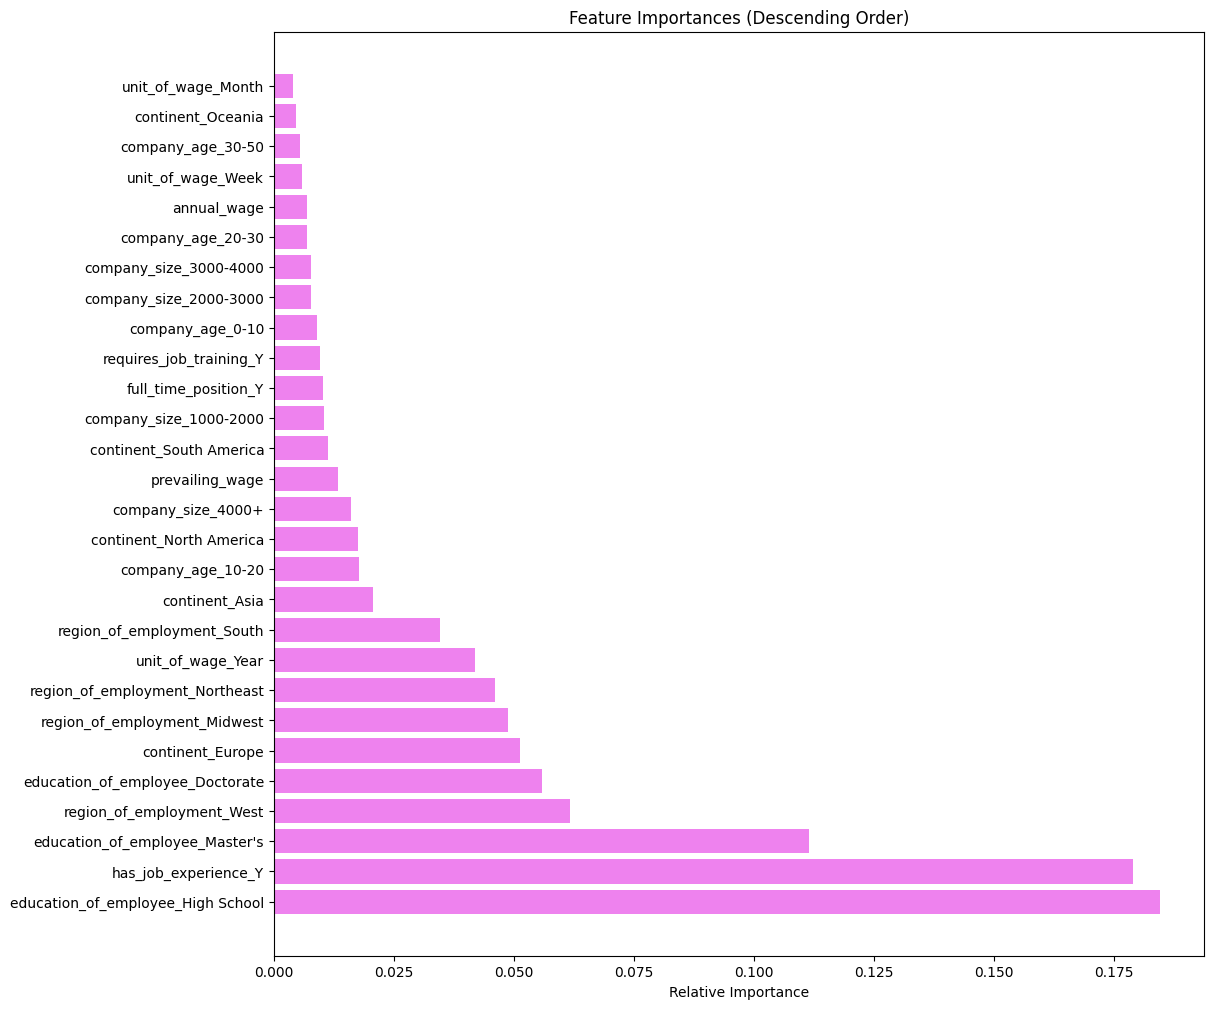

In [113]:
feature_names = X_train.columns
importances = tuned_xgb.feature_importances_
indices = np.argsort(importances)[::-1]  # Sorting in descending order
plt.figure(figsize=(12, 12))
plt.title("Feature Importances (Descending Order)")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

**Top Features that influence Visa Certification/Approval status:**

1. **Education of employee (High School):**
This feature tops the chart, suggesting that whether or not the applicant has a high school level education is a very strong indicator in the models decision process.

2. **Has job experience (Y):**
The fact that the applicants work experience carries high importance means that having prior job experience is a key factor in deciding visa approval.

3. **Education of employee (Masters):**
The presence of a masters degree is another influential factor, indicating that higher education credentials beyond high school are considered by the model.

4. **Region of employment (West):**
This regional factor is a significant contributor—implying that where the job is located (in this case, the West region) has a notable impact on visa decisions.

5. **Education of employee (Doctorate):**
Advanced education, such as a doctorate, also plays an important role.

6. **Continent (Europe):**
The applicants country or continent (specifically Europe) adds to the decision-making process.


Additional features like** Region of employment (Midwest, Northeast, South)** and **Unit of wage (Year)** also contribute, though with relatively lower importances compared to the top features mentioned above.

<font size=6 color='blue'>Power Ahead</font>
___